## Training a Single Layer Neural Network with Time Series Data

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### Utilities

In [2]:
def plot_series(time, series, format="-", start=0, end=None):
    """
    Visualizes time series data

    Args:
      time (array of int) - contains the time steps
      series (array of int) - contains the measurements for each time step
      format - line style when plotting the graph
      label - tag for the line
      start - first time step to plot
      end - last time step to plot
    """

    # Setup dimensions of the graph figure
    plt.figure(figsize=(10, 6))
    
    if type(series) is tuple:

      for series_num in series:
        # Plot the time series data
        plt.plot(time[start:end], series_num[start:end], format)

    else:
      # Plot the time series data
      plt.plot(time[start:end], series[start:end], format)

    # Label the x-axis
    plt.xlabel("Time")

    # Label the y-axis
    plt.ylabel("Value")

    # Overlay a grid on the graph
    plt.grid(True)

    # Draw the graph on screen
    plt.show()


def trend(time, slope=0):
    """
    Generates synthetic data that follows a straight line given a slope value.

    Args:
      time (array of int) - contains the time steps
      slope (float) - determines the direction and steepness of the line

    Returns:
      series (array of float) - measurements that follow a straight line
    """

    # Compute the linear series given the slope
    series = slope * time

    return series


def seasonal_pattern(season_time):
    """
    Just an arbitrary pattern, you can change it if you wish
    
    Args:
      season_time (array of float) - contains the measurements per time step

    Returns:
      data_pattern (array of float) -  contains revised measurement values according 
                                  to the defined pattern
    """

    # Generate the values using an arbitrary pattern
    data_pattern = np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))
    
    return data_pattern


def seasonality(time, period, amplitude=1, phase=0):
    """
    Repeats the same pattern at each period

    Args:
      time (array of int) - contains the time steps
      period (int) - number of time steps before the pattern repeats
      amplitude (int) - peak measured value in a period
      phase (int) - number of time steps to shift the measured values

    Returns:
      data_pattern (array of float) - seasonal data scaled by the defined amplitude
    """
    
    # Define the measured values per period
    season_time = ((time + phase) % period) / period

    # Generates the seasonal data scaled by the defined amplitude
    data_pattern = amplitude * seasonal_pattern(season_time)

    return data_pattern


def noise(time, noise_level=1, seed=None):
    """Generates a normally distributed noisy signal

    Args:
      time (array of int) - contains the time steps
      noise_level (float) - scaling factor for the generated signal
      seed (int) - number generator seed for repeatability

    Returns:
      noise (array of float) - the noisy signal
    """

    # Initialize the random number generator
    rnd = np.random.RandomState(seed)

    # Generate a random number for each time step and scale by the noise level
    noise = rnd.randn(len(time)) * noise_level
    
    return noise

### Generate synthetic data

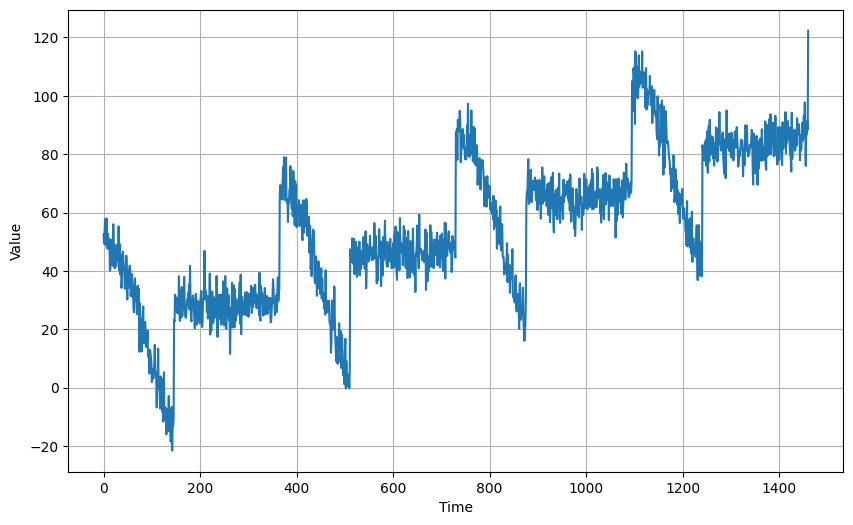

In [3]:
# Parameters
time = np.arange(4 * 365 + 1, dtype="float32")
baseline = 10
amplitude = 40
slope = 0.05
noise_level = 5

# Create the series
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)

# Update with noise
series += noise(time, noise_level, seed=42)

# Plot the results
plot_series(time, series)

### Split the dataset

In [4]:
split_time = 1000

# Training set 0 -> split_time-1
time_train = time[:split_time]
x_train = series[:split_time]

# Validation set split_time -> end
time_valid = time[split_time:]
x_valid = series[split_time:]

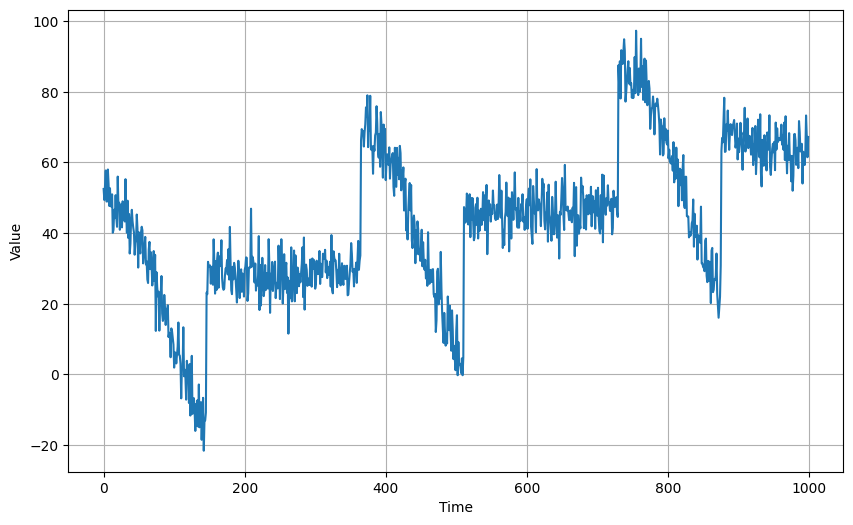

In [5]:
plot_series(time_train, x_train)

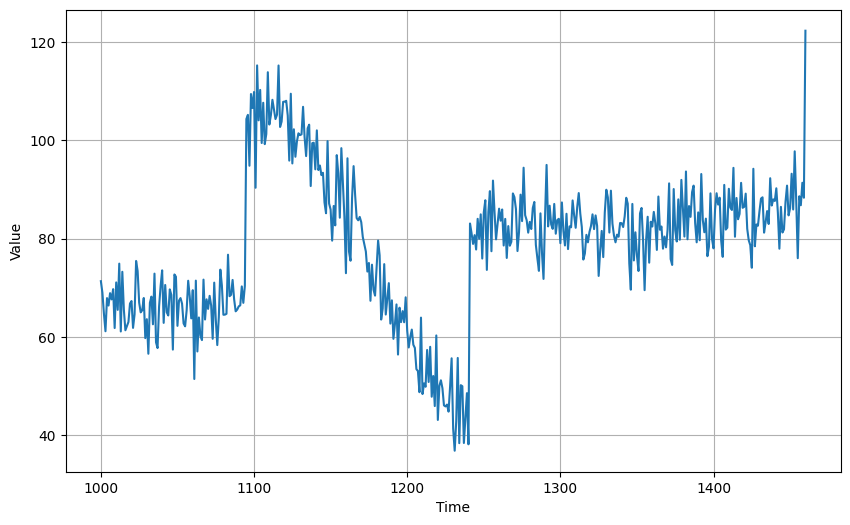

In [6]:
plot_series(time_valid, x_valid)

### Prepare features & labels

<br>

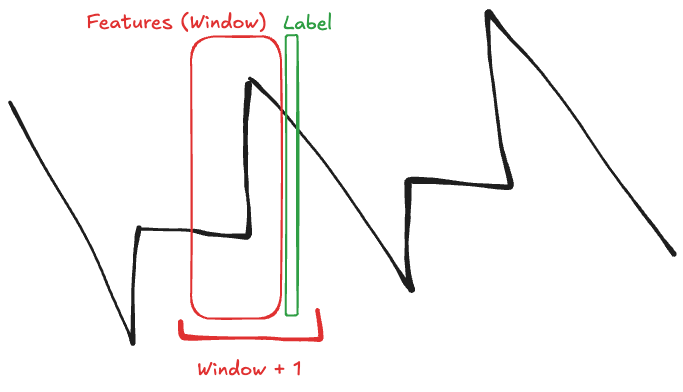

In [7]:
window_size = 20
batch_size = 30
shuffle_buffer_size = 1000

In [8]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)
    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
    # Create tuples with features and labels 
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))
    # Shuffle the windows
    dataset = dataset.shuffle(shuffle_buffer)
    # Create batches of windows
    dataset = dataset.batch(batch_size)
    # Optimize the dataset for training
    dataset = dataset.cache().prefetch(1)
    
    return dataset

In [9]:
dataset = windowed_dataset(series, window_size, batch_size, shuffle_buffer_size)

I0000 00:00:1758015688.980531 7575231 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1758015688.980566 7575231 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
for windows in dataset.take(1):
    print(f'data type: {type(windows)}')
    print(f'number of elements in the tuple: {len(windows)}')
    print(f'shape of first element: {windows[0].shape}')
    print(f'shape of second element: {windows[1].shape}')
    print(windows[1])

data type: <class 'tuple'>
number of elements in the tuple: 2
shape of first element: (30, 20)
shape of second element: (30,)
tf.Tensor(
[68.98551   63.12085   11.465986  35.255863  30.446434  61.464104
 29.614908  36.145657  34.92262   23.403429  32.631824  81.65221
 66.15852   26.50489   25.05581    4.8520856 23.888557  59.268875
 76.01741   22.06895   62.228306  36.417343  26.994549  63.610905
 61.271942  31.43617   68.890526  34.145004  66.73431   39.88281  ], shape=(30,), dtype=float32)


2025-09-16 15:11:29.137469: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Build and compile - Single layer neural network model

In [11]:
dense0 = tf.keras.layers.Dense(1)
input_layer = tf.keras.Input(shape=(window_size,))
output_layer = dense0(input_layer)

model = tf.keras.Model(input_layer, output_layer)

print(f"Layer weights: \n {dense0.get_weights()} \n")
model.summary()

Layer weights: 
 [array([[-3.6916834e-01],
       [-3.9114892e-01],
       [ 9.1001034e-02],
       [ 3.0236691e-01],
       [ 1.3024813e-01],
       [ 8.0053508e-02],
       [ 1.2791532e-01],
       [ 1.9320375e-01],
       [-3.8475525e-01],
       [ 3.1114167e-01],
       [ 5.2872950e-01],
       [ 3.1255013e-01],
       [ 1.9562387e-01],
       [ 7.5720549e-02],
       [ 3.0136865e-01],
       [-4.4822693e-04],
       [ 4.7446853e-01],
       [-3.9820135e-01],
       [-4.8885241e-01],
       [-4.5222178e-01]], dtype=float32), array([0.], dtype=float32)] 



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss="mse", optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))

In [13]:
model.fit(dataset, epochs=100)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 420.2753
Epoch 2/100
38/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 283.4023

/Users/opmule/miniforge3/envs/ai_tensorflow/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 270.1678
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 227.5360
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 197.6649
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 175.2198
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 157.4875
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 143.0297
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 131.0135
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 120.9055
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 112.3323
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105.0149
Epoch 12/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 98.7357 
Epoch 13/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 93.3210
Epoch 14/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 88.6295
Epoch 15/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 84.5459
Epoch 16/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - los

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.9641
Epoch 83/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.9393
Epoch 84/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.9159
Epoch 85/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.8940
Epoch 86/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.8733
Epoch 87/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.8538
Epoch 88/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.8355
Epoch 89/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.8182
Epoch 90/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.8020
Epoch 91/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.7867
Epoch 92/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.7723
Epoch 93/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.7588
Epoch 94/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.7461
Epoch 95/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.7341
Epoch 96/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4

In [14]:
print(f"Layer weights: \n {dense0.get_weights()} \n")


Layer weights: 
 [array([[-0.01926313],
       [-0.03863629],
       [ 0.05024878],
       [ 0.00392538],
       [ 0.03466317],
       [-0.02338587],
       [-0.01280846],
       [ 0.02832971],
       [-0.03129182],
       [ 0.00179586],
       [ 0.03416482],
       [ 0.02073355],
       [-0.03982511],
       [ 0.01762539],
       [ 0.02516323],
       [ 0.02676111],
       [ 0.08035231],
       [ 0.18067166],
       [ 0.2677857 ],
       [ 0.4127221 ]], dtype=float32), array([0.01880438], dtype=float32)] 



### Model prediction

In [17]:
forecast = []

for time in range(len(series)-window_size):
    forecast.append(model.predict(series[time:time+window_size][np.newaxis], verbose=0))
    
forecast = forecast[split_time - window_size:]
# Compare number of elements in the predictions and the validation set
print(f'length of the forecast list: {len(forecast)}')
print(f'shape of the validation set: {x_valid.shape}')

length of the forecast list: 461
shape of the validation set: (461,)


shape after converting to numpy array: (461, 1, 1)
shape after squeezing: (461,)


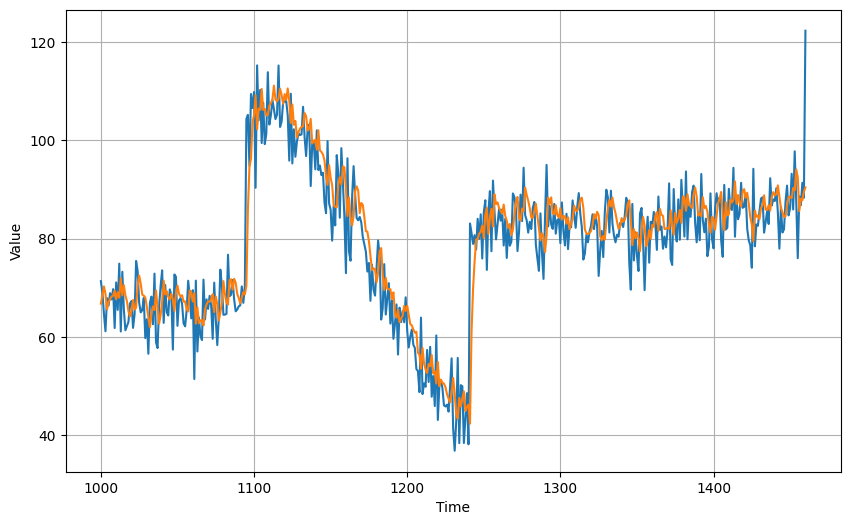

In [18]:
# Preview shapes after using the conversion and squeeze methods
print(f'shape after converting to numpy array: {np.array(forecast).shape}')
print(f'shape after squeezing: {np.array(forecast).squeeze().shape}')

# Convert to a numpy array and drop single dimensional axes
results = np.array(forecast).squeeze()

# Overlay the results with the validation set
plot_series(time_valid, (x_valid, results))

In [19]:
# Compute the metrics
print(tf.keras.metrics.mse(x_valid, results).numpy())
print(tf.keras.metrics.mae(x_valid, results).numpy())

45.412186
5.111807
